# 02 – Model Training & Results Analysis

Train ELSA + TopK SAE models on Yelp recommendation data and analyze results.

**Pre-requisites**: Run `00_preprocessing.ipynb` first to generate:
- `user2index.pkl` and `item2index.pkl` - Global user/item ID mappings
- `R_full.npz` - Full CSR matrix of all user-item interactions
- `metadata.json` - Preprocessing metadata

Then this notebook will:
1. Load the global CSR matrix
2. Filter by state (if configured)
3. Apply k-core filtering
4. Train models

In [ ]:
import sys
from pathlib import Path
import pickle
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from scipy.sparse import load_npz, csr_matrix
import scipy.sparse as sp
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, Subset

# Handle imports from src
# Ensure src/ is in Python path (works regardless of current directory)
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Now import from src/
from src.utils import Config, load_config
from src.models.collaborative_filtering import ELSA, recall_at_k, ndcg_at_k
from src.models.sparse_autoencoder import TopKSAE, topk_mask

print(f"✓ Project root: {project_root}")
print(f"✓ All imports successful")
print(f"\nPyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

✓ Imports successful (added C:\Users\elisk\Desktop\2024-25\Diplomka\Github\Diplomov-pr-ce to path)

PyTorch version: 2.10.0+cpu
CUDA available: False


## 1. Load Configuration & Data

In [ ]:
# Load config - find project root dynamically
project_root = Path(".").resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent

config_path = project_root / "configs" / "default.yaml"

# Try to load config
try:
    config = load_config(str(config_path))
    print(f"✓ Config loaded from: {config_path}")
except Exception as e:
    print(f"⚠ Error loading config: {e}")
    print(f"   Looked for: {config_path}")

# ============================================================================
# DATA PATH SETUP & DEVICE CONFIGURATION
# ============================================================================
# Set device for torch (ONCE - reused throughout notebook)
device = "cuda" if torch.cuda.is_available() else "cpu"

# Data paths (preprocessed data)
PREPROCESS_DIR = project_root / "data" / "preprocessed_yelp"

# Verify preprocessing completed
if not PREPROCESS_DIR.exists():
    print(f"⚠ Preprocessing data not found: {PREPROCESS_DIR}")
    print(f"   Run: python -m src.preprocess_data --config configs/default.yaml")
else:
    print(f"✓ Preprocessed data found: {PREPROCESS_DIR}")

# Create timestamped output directory + symlink to "latest"
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUTS_DIR = project_root / "outputs" / timestamp
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

# Create symlink to latest output for notebook 03 discovery
latest_link = project_root / "outputs" / "latest"
if latest_link.exists():
    latest_link.unlink()
try:
    latest_link.symlink_to(OUTPUTS_DIR)
except (OSError, NotImplementedError):
    # Windows may not support symlinks - fallback to creating LATEST_RUN.txt
    with open(project_root / "outputs" / "LATEST_RUN.txt", "w") as f:
        f.write(str(OUTPUTS_DIR))

# Setup checkpoint manager early (before any checkpoint operations)
checkpoint_dir = OUTPUTS_DIR / "checkpoints"
checkpoint_dir.mkdir(parents=True, exist_ok=True)

print(f"✓ Preprocessed dir: {PREPROCESS_DIR}")
print(f"✓ Output directory: {OUTPUTS_DIR}")
print(f"✓ Symlink/marker: {latest_link}")
print(f"✓ Device: {device}")

✓ Config loaded from: C:\Users\elisk\Desktop\2024-25\Diplomka\Github\Diplomov-pr-ce\configs\default.yaml
✓ Parquet dir: C:\Users\elisk\Desktop\2024-25\Diplomka\Github\Diplomov-pr-ce\..\..\Yelp-JSON\yelp_parquet
✓ Preprocessed dir: C:\Users\elisk\Desktop\2024-25\Diplomka\Github\Diplomov-pr-ce\data\preprocessed_yelp
✓ Output directory: C:\Users\elisk\Desktop\2024-25\Diplomka\Github\Diplomov-pr-ce\outputs\20260409_132816
✓ Symlink/marker: C:\Users\elisk\Desktop\2024-25\Diplomka\Github\Diplomov-pr-ce\outputs\latest
✓ Device: cpu


## 2. Load and Preprocess Data

In [3]:
# Import pipeline functions (not defined in notebook)
from src.data.yelp_loader import load_reviews, load_businesses
from src.data.preprocessing import apply_kcore_filtering, build_csr
from src.train import train_elsa, train_sae, SparseDataset
from src.utils import CheckpointManager

# ============================================================================
# VALIDATE CONFIGURATION
# ============================================================================
print("="*80)
print("CONFIGURATION VALIDATION")
print("="*80)

errors = []

# Check state_filter if specified
state_filter = config['data'].get('state_filter')
if state_filter:
    expected_file = PREPROCESS_DIR / f"R_{state_filter}_compact.npz"
    if not expected_file.exists():
        errors.append(f"State-filtered CSR not found: {expected_file}")

# Check k_core value
k_core_val = config['data'].get('k_core', 5)
if k_core_val < 0:
    errors.append(f"k_core must be >= 0, got {k_core_val}")

# Check train_test_split is valid
train_split_ratio = config['data'].get('train_test_split', 0.8)
if not (0 < train_split_ratio < 1):
    errors.append(f"train_test_split must be in (0, 1), got {train_split_ratio}")

# Check val_split
val_split_ratio = config['data'].get('val_split', 0.2)
if not (0 < val_split_ratio < 1):
    errors.append(f"val_split must be in (0, 1), got {val_split_ratio}")

# Check preprocessing directory exists
if not PREPROCESS_DIR.exists():
    errors.append(f"Preprocessing directory not found: {PREPROCESS_DIR}")

if errors:
    print("\n❌ CONFIG VALIDATION FAILED:")
    for err in errors:
        print(f"  - {err}")
    raise ValueError("Configuration validation failed. See errors above.")
else:
    print("\n✓ Configuration validation passed")
    print(f"  - state_filter: {state_filter if state_filter else 'None (all states)'}")
    print(f"  - k_core: {k_core_val}")
    print(f"  - train_test_split: {train_split_ratio}")
    print(f"  - val_split: {val_split_ratio}")
    print()

# ============================================================================
# LOAD AND PREPROCESS DATA
# ============================================================================
print("="*80)
print("STEP 1: LOAD AND PREPROCESS DATA")
print("="*80)

# Load ID mappings
user_map_path = PREPROCESS_DIR / "user2index.pkl"
item_map_path = PREPROCESS_DIR / "item2index.pkl"

with open(user_map_path, "rb") as f:
    user_map = pickle.load(f)
with open(item_map_path, "rb") as f:
    item_map = pickle.load(f)

print(f"✓ Loaded user2index.pkl ({len(user_map):,} users)")
print(f"✓ Loaded item2index.pkl ({len(item_map):,} items)")

# Load CSR matrix (full or state-specific based on config)
if state_filter:
    # Load state-specific CSR (compact version without zero rows/columns)
    csr_path = PREPROCESS_DIR / f"R_{state_filter}_compact.npz"
    X_csr = load_npz(csr_path).astype(np.float32)
    print(f"✓ Loaded R_{state_filter}_compact.npz")
    print(f"  State: {state_filter} (compact - active users only)")
    print(f"  Shape: {X_csr.shape[0]:,} active users × {X_csr.shape[1]:,} active items")
    print(f"  Interactions: {X_csr.nnz:,}")
else:
    # Load full CSR matrix
    csr_path = PREPROCESS_DIR / "R_full.npz"
    X_csr = load_npz(csr_path).astype(np.float32)
    print(f"✓ Loaded R_full.npz (all states)")
    print(f"  Shape: {X_csr.shape[0]:,} users × {X_csr.shape[1]:,} items")
    print(f"  Interactions: {X_csr.nnz:,}")

# Apply k-core filtering
print(f"\nApplying k-core filtering (k={k_core_val})...")
X_csr_before = X_csr.copy()
X_csr = apply_kcore_filtering(X_csr, k=k_core_val)
print(f"✓ After k-core: {X_csr.shape[0]:,} users × {X_csr.shape[1]:,} items")
print(f"  Interactions: {X_csr.nnz:,} (removed {X_csr_before.nnz - X_csr.nnz:,})")


CONFIGURATION VALIDATION

✓ Configuration validation passed
  - state_filter: PA
  - k_core: 5
  - train_test_split: 0.8
  - val_split: 0.1

STEP 1: LOAD AND PREPROCESS DATA
✓ Loaded user2index.pkl (1,464,850 users)
✓ Loaded item2index.pkl (147,491 items)
✓ Loaded R_PA_compact.npz
  State: PA (compact - active users only)
  Shape: 312,624 active users × 33,377 active items
  Interactions: 1,019,228

Applying k-core filtering (k=5)...
✓ After k-core: 39,692 users × 17,388 items
  Interactions: 565,126 (removed 454,102)


## 3. Create Train/Val/Test Splits

In [4]:
# Train/test split by users
n_users = X_csr.shape[0]
user_indices = np.arange(n_users)

# Explicit: train_split_ratio determines fraction for training
# e.g., train_split_ratio=0.8 → 80% train, 20% test
train_split_ratio = config['data']['train_test_split']
test_split_ratio = 1.0 - train_split_ratio

train_users, test_users = train_test_split(
    user_indices,
    test_size=test_split_ratio,  # Explicit parameter naming
    random_state=config['data']['seed'],
)

X_train_csr = X_csr[train_users]
X_test_csr = X_csr[test_users]

# Create sparse dataset wrappers
X_train_dataset = SparseDataset(X_train_csr)
X_test_dataset = SparseDataset(X_test_csr)

# Train/val split on training set (indices are RELATIVE to X_train_csr, not global)
train_indices = np.arange(X_train_csr.shape[0])
val_split_ratio = config['data']['val_split']
train_idx, val_idx = train_test_split(
    train_indices,
    test_size=val_split_ratio,
    random_state=config['data']['seed'],
)

X_train_split = Subset(X_train_dataset, train_idx)
X_val_split = Subset(X_train_dataset, val_idx)

# Initialize checkpoint manager (already created checkpoints dir in Cell 4)
checkpoint_mgr = CheckpointManager(checkpoint_dir)

print(f"✓ Data splits created:")
print(f"  Train: {len(train_idx):,} users")
print(f"  Val: {len(val_idx):,} users")
print(f"  Test: {len(test_users):,} users")
print(f"  Note: train_idx and val_idx are relative indices within X_train_csr")
print(f"✓ Checkpoint manager initialized: {checkpoint_dir}")

✓ Data splits created:
  Train: 28,577 users
  Val: 3,176 users
  Test: 7,939 users
  Note: train_idx and val_idx are relative indices within X_train_csr
✓ Checkpoint manager initialized: C:\Users\elisk\Desktop\2024-25\Diplomka\Github\Diplomov-pr-ce\outputs\20260409_132816\checkpoints


In [ ]:
print("\n" + "="*80)
print("STEP 2: SAVE DATA FOR NOTEBOOK 03 (NEURON LABELING)")
print("="*80)

# Save to outputs directory for easy access by notebook 03
data_save_dir = OUTPUTS_DIR / "data"
data_save_dir.mkdir(parents=True, exist_ok=True)

print(f"\nDataset Info:")
print(f"  State filter: {state_filter if state_filter else 'None (all states)'}")
print(f"  K-core threshold: {k_core_val}")
print(f"  Total users: {X_csr.shape[0]:,}")
print(f"  Total items: {X_csr.shape[1]:,}")
print(f"  Total interactions: {X_csr.nnz:,}")

# Save full CSR matrix for notebook 03
# Format: scipy.sparse.csr_matrix in .npz format (sparse, compressed)
full_csr_path = data_save_dir / "X_csr.npz"
sp.save_npz(full_csr_path, X_csr)
file_size_mb = full_csr_path.stat().st_size / (1024 * 1024)
print(f"\n✓ Saved CSR matrix: {full_csr_path}")
print(f"  Format: scipy.sparse CSR (compressed)")
print(f"  Size: {file_size_mb:.1f} MB")
print(f"  Shape: {X_csr.shape} (users × items)")
print(f"  Sparsity: {100 * (1 - X_csr.nnz / (X_csr.shape[0] * X_csr.shape[1])):.1f}%")

# ⭐ CREATE FILTERED ITEM MAPPING (after k-core filtering)
# The CSR matrix columns are renumbered after k-core, so we need to track which items survived
print(f"\n⭐ Creating filtered item mapping (post-k-core)...")

# Build mapping from original indices (before k-core) to business_ids
index_to_business_before = {idx: bid for bid, idx in item_map.items()}

# Get all items that are actually used in the k-core filtered matrix (column indices with non-zeros)
item_indices_used = set(X_csr.nonzero()[1])  # Column indices of non-zero entries

# Build new mapping: business_id -> new_index (only items in k-core result)
items_after_kcore = sorted(item_indices_used)
item_map_filtered = {
    index_to_business_before[old_idx]: new_idx
    for new_idx, old_idx in enumerate(items_after_kcore)
}

print(f"  Item mapping: {len(item_map):,} (universal) → {len(item_map_filtered):,} (filtered)")

# Save FILTERED item mapping (what model actually uses!)
item_map_filtered_path = data_save_dir / "item2index.pkl"
with open(item_map_filtered_path, "wb") as f:
    pickle.dump(item_map_filtered, f)
print(f"✓ Saved FILTERED item2index.pkl: {len(item_map_filtered):,} items (post-k-core)")

# Also save universal mappings for reference
item_map_universal_path = data_save_dir / "item2index_universal.pkl"
with open(item_map_universal_path, "wb") as f:
    pickle.dump(item_map, f)
print(f"✓ Saved UNIVERSAL item2index_universal.pkl: {len(item_map):,} items (reference only)")

# Save user mapping (unchanged by k-core)
user_map_save_path = data_save_dir / "user2index.pkl"
with open(user_map_save_path, "wb") as f:
    pickle.dump(user_map, f)
print(f"✓ Saved user2index.pkl: {len(user_map):,} users")

print(f"\n✓ Data saved for notebook 03!")
print(f"  Location: {data_save_dir}")
print(f"  IMPORTANT: Use item2index.pkl (filtered), NOT item2index_universal.pkl")
print(f"  Latest symlink: {project_root / 'outputs' / 'latest'}")



STEP 2: SAVE DATA FOR NOTEBOOK 03 (NEURON LABELING)

Dataset Info:
  State filter: PA
  K-core threshold: 5
  Total users: 39,692
  Total items: 17,388
  Total interactions: 565,126



✓ Saved CSR matrix: C:\Users\elisk\Desktop\2024-25\Diplomka\Github\Diplomov-pr-ce\outputs\20260409_132816\data\X_csr.npz
  Format: scipy.sparse CSR (compressed)
  Size: 1.2 MB
  Shape: (39692, 17388) (users × items)
  Sparsity: 99.9%

✓ Saved ID mappings:
  user2index.pkl: 1,464,850 users (pickle format)
  item2index.pkl: 147,491 items (pickle format)

✓ Data saved for notebook 03!
  Location: C:\Users\elisk\Desktop\2024-25\Diplomka\Github\Diplomov-pr-ce\outputs\20260409_132816\data
  Latest symlink: C:\Users\elisk\Desktop\2024-25\Diplomka\Github\Diplomov-pr-ce\outputs\latest


## 4. Train ELSA Model

In [6]:
# Train ELSA model using the existing training function
n_items = X_csr.shape[1]

print("=" * 70)
print("Training ELSA Model")
print("=" * 70)
print(f"\nDataset Info:")
print(f"  Training users: {len(train_idx):,}")
print(f"  Validation users: {len(val_idx):,}")
print(f"  Items: {n_items:,}")
print(f"  Config: batch_size={config['elsa']['batch_size']}, epochs={config['elsa']['num_epochs']}")
print(f"  Device: {config['elsa']['device']}")

import time
start_time = time.time()

elsa_model, elsa_best_loss = train_elsa(
    config=config,
    X_train=X_train_split,
    X_val=X_val_split,
    n_items=n_items,
    checkpoint_mgr=checkpoint_mgr,
)

elapsed = time.time() - start_time
print(f"\n✓ ELSA Training Complete ({elapsed:.1f}s total)")
print(f"  Best validation loss: {elsa_best_loss:.4f}")
print(f"  Model latent dimension: {elsa_model.latent_dim}")
print(f"  Average per epoch: {elapsed / config['elsa']['num_epochs']:.1f}s")

Training ELSA Model

Dataset Info:
  Training users: 28,577
  Validation users: 3,176
  Items: 17,388
  Config: batch_size=1024, epochs=25
  Device: cpu

✓ ELSA Training Complete (3490.6s total)
  Best validation loss: 0.0001
  Model latent dimension: 512
  Average per epoch: 139.6s


## 5. Encode User Interactions with ELSA

In [7]:
# Encode user interactions into latent space using trained ELSA
elsa_model.eval()

# Encode train/val/test data with chunk processing for memory efficiency
chunk_size = config['elsa'].get('encode_chunk_size', 4096)

print("Encoding users into latent space...")

# Get indices for train/val/test
Z_train_full = elsa_model.encode_csr_chunked(X_train_csr, chunk_size=chunk_size)
Z_test_full = elsa_model.encode_csr_chunked(X_test_csr, chunk_size=chunk_size)

# Create subsets matching train/val split
Z_train = Z_train_full[train_idx]
Z_val = Z_train_full[val_idx]
Z_test = Z_test_full  # Test users' full latent encodings

print(f"✓ User encodings complete")
print(f"  Train encodings: {Z_train.shape}")
print(f"  Val encodings: {Z_val.shape}")
print(f"  Test encodings: {Z_test.shape}")

Encoding users into latent space...
✓ User encodings complete
  Train encodings: torch.Size([28577, 512])
  Val encodings: torch.Size([3176, 512])
  Test encodings: torch.Size([7939, 512])


## 6. Train TopK Sparse Autoencoder (SAE)

In [8]:
# Train TopK Sparse Autoencoder using the existing training function
print("=" * 50)
print("Training TopK Sparse Autoencoder")
print("=" * 50)

sae_model, sae_best_loss = train_sae(
    config=config,
    elsa_model=elsa_model,
    Z_train=Z_train,
    Z_val=Z_val,
    checkpoint_mgr=checkpoint_mgr,
)

print(f"\n✓ SAE Training Complete")
print(f"  Best validation loss: {sae_best_loss:.4f}")

# Get SAE model info
sae_cfg = config['sae']
hidden_dim = sae_cfg['width_ratio'] * elsa_model.latent_dim
print(f"  Hidden dimension: {hidden_dim}")
print(f"  Top-k: {sae_cfg['k']}")

Training TopK Sparse Autoencoder

✓ SAE Training Complete
  Best validation loss: 0.2680
  Hidden dimension: 2048
  Top-k: 32


## 7. Visualize Training Progress

Loading training metrics...
✓ Loaded ELSA metrics: 2 keys
✓ Loaded SAE metrics: 4 keys


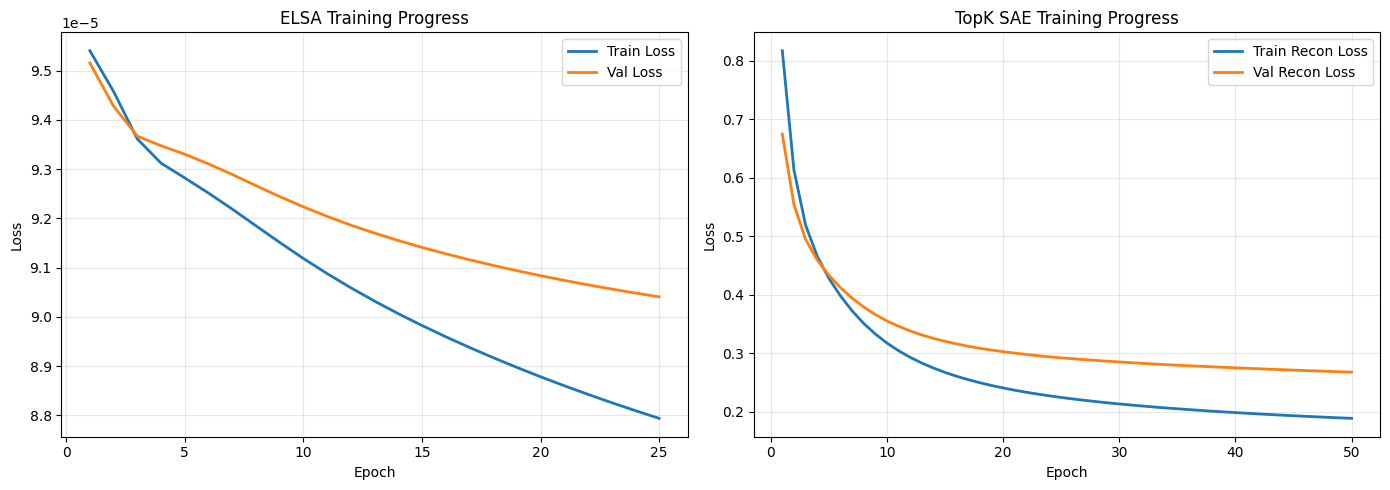

✓ Training progress visualization saved to C:\Users\elisk\Desktop\2024-25\Diplomka\Github\Diplomov-pr-ce\outputs\20260409_132816\training_progress.png


In [9]:
# ============================================================================
# LOAD TRAINING METRICS (ONE TIME - REUSED THROUGHOUT NOTEBOOK)
# ============================================================================
print("="*80)
print("Loading training metrics...")
print("="*80)

elsa_metrics_file = checkpoint_mgr.checkpoint_dir / 'metrics_elsa_train.json'
sae_metrics_file = checkpoint_mgr.checkpoint_dir / 'metrics_sae_train.json'

elsa_metrics = {}
sae_metrics = {}

if elsa_metrics_file.exists():
    with open(elsa_metrics_file, 'r') as f:
        elsa_metrics = json.load(f)
    print(f"✓ Loaded ELSA metrics: {len(elsa_metrics)} keys")
    
if sae_metrics_file.exists():
    with open(sae_metrics_file, 'r') as f:
        sae_metrics = json.load(f)
    print(f"✓ Loaded SAE metrics: {len(sae_metrics)} keys")

# ============================================================================
# VISUALIZE TRAINING PROGRESS
# ============================================================================
# Plot training progress if metrics are available
if elsa_metrics or sae_metrics:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # ELSA training progress
    if elsa_metrics:
        epochs = range(1, len(elsa_metrics['train_loss']) + 1)
        axes[0].plot(epochs, elsa_metrics['train_loss'], label='Train Loss', linewidth=2)
        axes[0].plot(epochs, elsa_metrics['val_loss'], label='Val Loss', linewidth=2)
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('ELSA Training Progress')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
    
    # SAE training progress
    if sae_metrics:
        epochs = range(1, len(sae_metrics['train_recon']) + 1)
        axes[1].plot(epochs, sae_metrics['train_recon'], label='Train Recon Loss', linewidth=2)
        axes[1].plot(epochs, sae_metrics['val_recon'], label='Val Recon Loss', linewidth=2)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Loss')
        axes[1].set_title('TopK SAE Training Progress')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / 'training_progress.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Training progress visualization saved to {OUTPUTS_DIR / 'training_progress.png'}")
else:
    print("⚠ No metrics files found. Skipping visualization.")

## 8. Analyze Model Outputs

In [10]:
# Model statistics and training metrics (using already-loaded metrics from Cell 17)
print("=" * 70)
print("Trained Models Summary")
print("=" * 70)

# ELSA Model
print("\n[ELSA Model]")
print(f"  Latent dimension: {elsa_model.latent_dim}")
print(f"  Input items: {n_items:,}")
print(f"  Parameters: {sum(p.numel() for p in elsa_model.parameters()):,}")
if elsa_metrics:
    print(f"  Training epochs: {len(elsa_metrics['train_loss'])}")
    print(f"  Best val loss: {min(elsa_metrics['val_loss']):.6f}")

# SAE Model
sae_cfg = config['sae']
hidden_dim = sae_cfg['width_ratio'] * elsa_model.latent_dim

print("\n[TopK SAE Model]")
print(f"  Input dimension: {elsa_model.latent_dim}")
print(f"  Hidden dimension: {hidden_dim} (width_ratio={sae_cfg['width_ratio']})")
print(f"  Top-k activation: {sae_cfg['k']} / {hidden_dim} ({sae_cfg['k']/hidden_dim*100:.2f}%)")
print(f"  Parameters: {sum(p.numel() for p in sae_model.parameters()):,}")
if sae_metrics:
    print(f"  Training epochs: {len(sae_metrics['train_recon'])}")
    print(f"  Best val loss: {min(sae_metrics['val_recon']):.6f}")

# Training dynamics
if elsa_metrics and sae_metrics:
    print("\n[Training Dynamics]")
    print(f"  ELSA - Train loss: {elsa_metrics['train_loss'][0]:.6f} → {elsa_metrics['train_loss'][-1]:.6f}")
    print(f"  SAE  - Train loss: {sae_metrics['train_recon'][0]:.6f} → {sae_metrics['train_recon'][-1]:.6f}")

Trained Models Summary

[ELSA Model]
  Latent dimension: 512
  Input items: 17,388
  Parameters: 8,902,656
  Training epochs: 25
  Best val loss: 0.000090

[TopK SAE Model]
  Input dimension: 512
  Hidden dimension: 2048 (width_ratio=4)
  Top-k activation: 32 / 2048 (1.56%)
  Parameters: 2,097,664
  Training epochs: 50
  Best val loss: 0.268025

[Training Dynamics]
  ELSA - Train loss: 0.000095 → 0.000088
  SAE  - Train loss: 0.817079 → 0.189060


## 9. Save Models and Results

In [11]:
# Save models, metrics, and results (metrics already loaded in Cell 17)
# Create results summary
results_summary = {
    'timestamp': datetime.now().isoformat(),
    'config': {
        'data': dict(config['data']),
        'elsa': dict(config['elsa']),
        'sae': dict(config['sae']),
    },
    'metrics': {
        'elsa': {
            'best_loss': float(elsa_best_loss),
            'n_epochs': len(elsa_metrics.get('train_loss', [])),
            'final_train_loss': float(elsa_metrics.get('train_loss', [0])[-1]) if elsa_metrics.get('train_loss') else None,
            'final_val_loss': float(elsa_metrics.get('val_loss', [0])[-1]) if elsa_metrics.get('val_loss') else None,
        },
        'sae': {
            'best_loss': float(sae_best_loss),
            'n_epochs': len(sae_metrics.get('train_recon', [])),
            'final_train_loss': float(sae_metrics.get('train_recon', [0])[-1]) if sae_metrics.get('train_recon') else None,
            'final_val_loss': float(sae_metrics.get('val_recon', [0])[-1]) if sae_metrics.get('val_recon') else None,
        }
    },
    'data_shapes': {
        'train_users': len(train_idx),
        'val_users': len(val_idx),
        'test_users': len(test_users),
        'n_items': n_items,
        'latent_dim': elsa_model.latent_dim,
    }
}

# Save results summary
results_file = OUTPUTS_DIR / 'training_results.json'
with open(results_file, 'w') as f:
    json.dump(results_summary, f, indent=2, default=str)

# Save universal mappings to outputs directory (matching src/train.py behavior)
# These are the preprocessed mappings that cover ALL items, before filtering
mappings_dir = OUTPUTS_DIR / "mappings"
mappings_dir.mkdir(parents=True, exist_ok=True)

user_map_universal_path = mappings_dir / "user2index_universal.pkl"
item_map_universal_path = mappings_dir / "business2index_universal.pkl"

with open(user_map_universal_path, "wb") as f:
    pickle.dump(user_map, f)
with open(item_map_universal_path, "wb") as f:
    pickle.dump(item_map, f)

print("=" * 50)
print("Training Summary")
print("=" * 50)
print(f"\n✓ Results saved to:")
print(f"  - {results_file}")
print(f"  - Checkpoints: {checkpoint_mgr.checkpoint_dir}")
print(f"  - Mappings: {mappings_dir}/")
print(f"    ├─ user2index_universal.pkl ({len(user_map):,} users)")
print(f"    └─ business2index_universal.pkl ({len(item_map):,} items)")
print(f"  - Training visualization: {OUTPUTS_DIR / 'training_progress.png'}")

print("\n✓ Models trained successfully!")
print(f"  ELSA best loss: {elsa_best_loss:.4f}")
print(f"  SAE best loss: {sae_best_loss:.4f}")

Training Summary

✓ Results saved to:
  - C:\Users\elisk\Desktop\2024-25\Diplomka\Github\Diplomov-pr-ce\outputs\20260409_132816\training_results.json
  - Checkpoints: C:\Users\elisk\Desktop\2024-25\Diplomka\Github\Diplomov-pr-ce\outputs\20260409_132816\checkpoints
  - Training visualization: C:\Users\elisk\Desktop\2024-25\Diplomka\Github\Diplomov-pr-ce\outputs\20260409_132816\training_progress.png

✓ Models trained successfully!
  ELSA best loss: 0.0001
  SAE best loss: 0.2680


## 10. Evaluate on Test Set

## 11. SAE Loss Analysis & Diagnosis

In [12]:
# ============================================================================
# EVALUATION SECTION - COMPLETE EVALUATION ON TEST SET
# ============================================================================

from src.models.sae_cf_model import ELSASAEModel

print("=" * 70)
print("Test Set Evaluation: ELSA vs ELSA+SAE")
print("=" * 70)

# Create combined model 
model = ELSASAEModel(
    n_items=X_test_csr.shape[1],
    latent_dim=elsa_model.latent_dim,
    sae_hidden_dim=2048,
    k=32,
    l1_coef=0.0003,
)

# Load weights
model.elsa.load_state_dict(elsa_model.state_dict())
model.sae.load_state_dict(sae_model.state_dict())
model.to(device)
model.eval()

# Evaluation storage
metrics_elsa = {'recall_20': [], 'recall_50': [], 'ndcg_20': [], 'ndcg_50': []}
metrics_sae = {'recall_20': [], 'recall_50': [], 'ndcg_20': [], 'ndcg_50': []}
k_values = [20, 50]

print(f"Evaluating on {X_test_csr.shape[0]} test users")
print(f"  - Holdout: 20% of items per user")
print(f"  - Evaluation metrics: Recall@20, Recall@50, NDCG@20, NDCG@50\n")

A_norm = model.elsa._A_norm  # Get normalized item matrix for decoding

with torch.no_grad():
    n_users_eval = 0
    n_invalid_users = 0
    
    for user_id in range(X_test_csr.shape[0]):
        user_full = X_test_csr.getrow(user_id).toarray().squeeze()
        
        # Skip users with no interactions
        if user_full.sum() == 0:
            n_invalid_users += 1
            continue
        
        # Split into holdout (20%) and training (80%)
        holdout_mask = np.random.RandomState(42 + user_id).binomial(1, 0.2, size=len(user_full))
        user_train = user_full.copy()
        user_train[holdout_mask.astype(bool)] = 0
        user_holdout = user_full * holdout_mask
        
        # Skip if no holdout items or no training items
        if user_holdout.sum() < 1 or user_train.sum() == 0:
            n_invalid_users += 1
            continue
        
        # Convert to tensor
        user_train_tensor = torch.tensor(user_train, dtype=torch.float32).unsqueeze(0).to(device)
        
        # Get latent code (normalized)
        z = model.elsa.encode(user_train_tensor)  # shape: (1, latent_dim), normalized
        
        # ELSA reconstruction: z @ A_norm.T
        elsa_recon = z @ A_norm.T
        elsa_scores = elsa_recon.cpu().numpy().squeeze()
        
        # SAE processing: get sparse reconstruction in latent space
        sae_z, _, _ = model.sae(z)  # SAE outputs reconstructed latent code
        
        # Decode SAE's latent output back to item space: sae_z @ A_norm.T
        sae_recon = sae_z @ A_norm.T
        sae_scores = sae_recon.cpu().numpy().squeeze()
        
        # Zero out training items (can't recommend what user already interacted with)
        elsa_scores[user_train > 0] = -np.inf
        sae_scores[user_train > 0] = -np.inf
        
        # Get top-50 predictions (for both Recall@20 and Recall@50)
        elsa_pred_ranked = np.argsort(-elsa_scores)[:50]
        sae_pred_ranked = np.argsort(-sae_scores)[:50]
        
        # Create binary labels for holdout items
        y_true = user_holdout.astype(np.int32)
        
        # Compute metrics
        for k in k_values:
            # ELSA metrics
            recall_elsa = recall_at_k(y_true, elsa_pred_ranked, k)
            ndcg_elsa = ndcg_at_k(y_true, elsa_pred_ranked, k)
            
            # SAE metrics
            recall_sae = recall_at_k(y_true, sae_pred_ranked, k)
            ndcg_sae = ndcg_at_k(y_true, sae_pred_ranked, k)
            
            # Store (use NaN for invalid cases)
            metrics_elsa[f'recall_{k}'].append(recall_elsa if not np.isnan(recall_elsa) else np.nan)
            metrics_elsa[f'ndcg_{k}'].append(ndcg_elsa)
            
            metrics_sae[f'recall_{k}'].append(recall_sae if not np.isnan(recall_sae) else np.nan)
            metrics_sae[f'ndcg_{k}'].append(ndcg_sae)
        
        n_users_eval += 1
        
        # Progress indicator
        if n_users_eval % max(1, X_test_csr.shape[0] // 10) == 0:
            print(f"  Evaluated {n_users_eval:,} users...")

print(f"\n✓ Evaluation complete!")
print(f"  Users evaluated: {n_users_eval:,}")
print(f"  Users skipped (invalid): {n_invalid_users:,}")
print(f"  Total test users: {X_test_csr.shape[0]:,}")


Test Set Evaluation: ELSA vs ELSA+SAE
Evaluating on 7939 test users
  - Holdout: 20% of items per user
  - Evaluation metrics: Recall@20, Recall@50, NDCG@20, NDCG@50

  Evaluated 793 users...
  Evaluated 1,586 users...
  Evaluated 2,379 users...
  Evaluated 3,172 users...
  Evaluated 3,965 users...
  Evaluated 4,758 users...
  Evaluated 5,551 users...
  Evaluated 6,344 users...

✓ Evaluation complete!
  Users evaluated: 6,637
  Users skipped (invalid): 1,302
  Total test users: 7,939


Computing mean metrics...
  recall_20    - ELSA: 0.0979, SAE: 0.0978
  recall_50    - ELSA: 0.1584, SAE: 0.1605
  ndcg_20      - ELSA: 0.0560, SAE: 0.0556
  ndcg_50      - ELSA: 0.0723, SAE: 0.0726

Generating evaluation visualization...


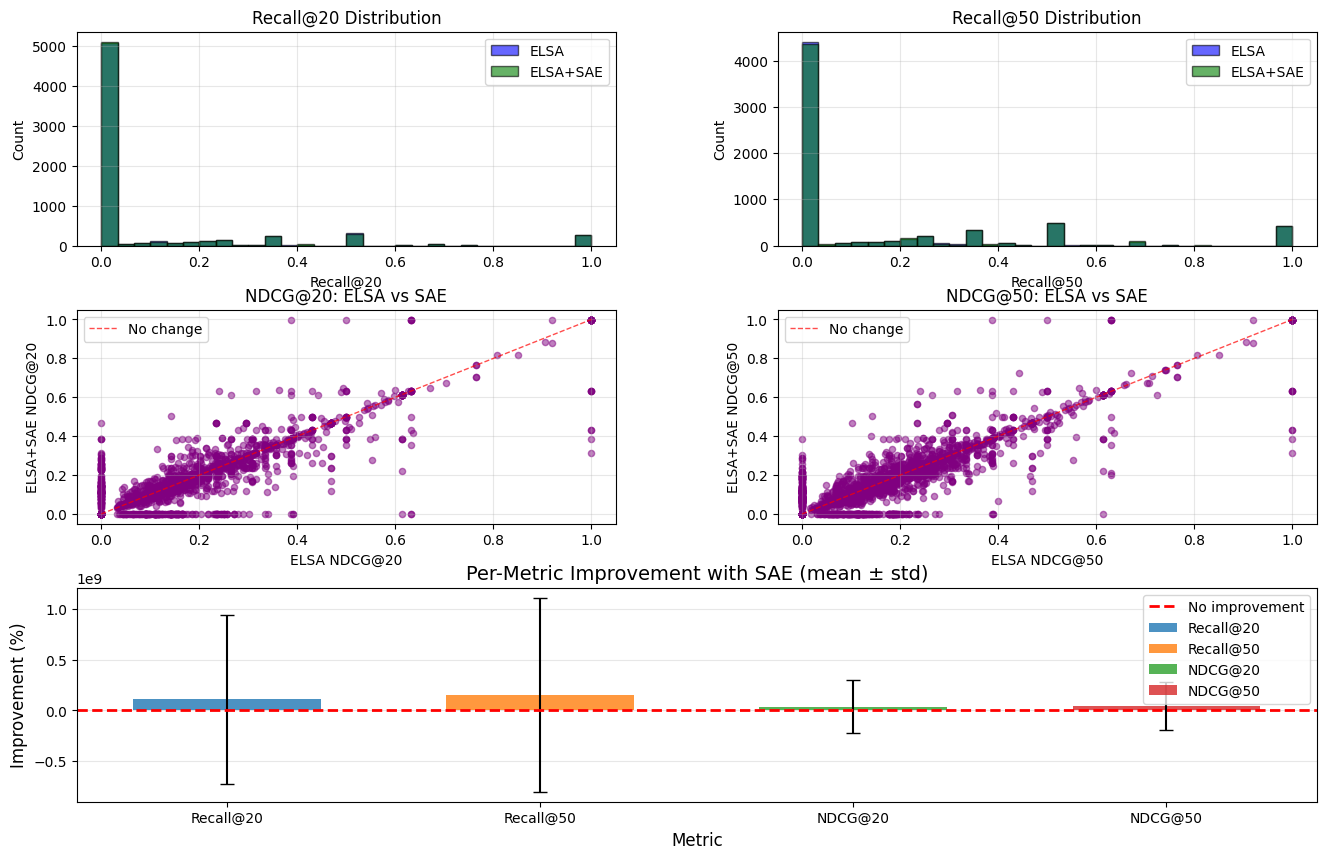

✓ Visualization saved to C:\Users\elisk\Desktop\2024-25\Diplomka\Github\Diplomov-pr-ce\outputs\20260409_132816\evaluation_metrics.png

Improvement with SAE:
  Recall@20      :   -0.15%
      ✓ 235 users improved, ✗ 249 declined
  Recall@50      :   +1.38%
      ✓ 383 users improved, ✗ 338 declined
  NDCG@20        :   -0.72%
      ✓ 688 users improved, ✗ 713 declined
  NDCG@50        :   +0.47%
      ✓ 1091 users improved, ✗ 1121 declined

✓ Evaluation complete! (6637 users)


In [14]:
# ============================================================================
# COMPUTE MEAN METRICS FROM EVALUATION RESULTS
# ============================================================================
print("Computing mean metrics...")

means_elsa = {}
means_sae = {}

for metric_key in metrics_elsa:
    # Convert lists to numpy arrays and filter NaN values
    elsa_vals = np.array(metrics_elsa[metric_key])
    sae_vals = np.array(metrics_sae[metric_key])
    
    # Filter out NaN values
    elsa_vals = elsa_vals[~np.isnan(elsa_vals)]
    sae_vals = sae_vals[~np.isnan(sae_vals)]
    
    # Compute means
    means_elsa[metric_key] = float(np.mean(elsa_vals)) if len(elsa_vals) > 0 else 0.0
    means_sae[metric_key] = float(np.mean(sae_vals)) if len(sae_vals) > 0 else 0.0
    
    print(f"  {metric_key:12s} - ELSA: {means_elsa[metric_key]:.4f}, SAE: {means_sae[metric_key]:.4f}")

# ============================================================================
# VISUALIZATION
# ============================================================================
print("\n" + "="*80)
print("Generating evaluation visualization...")
print("="*80)

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

metrics_to_plot = [
    ('recall_20', 'Recall@20'),
    ('recall_50', 'Recall@50'),
    ('ndcg_20', 'NDCG@20'),
    ('ndcg_50', 'NDCG@50'),
]

# Subplot 1-4: Distributions and scatter plots
for idx, (metric_key, metric_name) in enumerate(metrics_to_plot):
    if idx < 2:
        # Top row: Histograms
        ax = fig.add_subplot(gs[0, idx])
        elsa_vals = np.array(metrics_elsa[metric_key])
        sae_vals = np.array(metrics_sae[metric_key])
        
        elsa_vals = elsa_vals[~np.isnan(elsa_vals)]
        sae_vals = sae_vals[~np.isnan(sae_vals)]
        
        if len(elsa_vals) > 0 or len(sae_vals) > 0:
            ax.hist(elsa_vals, bins=30, alpha=0.6, label='ELSA', color='blue', edgecolor='black')
            ax.hist(sae_vals, bins=30, alpha=0.6, label='ELSA+SAE', color='green', edgecolor='black')
        ax.set_xlabel(metric_name)
        ax.set_ylabel('Count')
        ax.set_title(f'{metric_name} Distribution')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    elif 2 <= idx < 4:
        # Middle row: Scatter plots
        ax = fig.add_subplot(gs[1, idx-2])
        elsa_vals = np.array(metrics_elsa[metric_key])
        sae_vals = np.array(metrics_sae[metric_key])
        
        mask = ~(np.isnan(elsa_vals) | np.isnan(sae_vals))
        elsa_vals = elsa_vals[mask]
        sae_vals = sae_vals[mask]
        
        if len(elsa_vals) > 0:
            ax.scatter(elsa_vals, sae_vals, alpha=0.5, s=20, color='purple')
            lim = [min(elsa_vals.min(), sae_vals.min()), max(elsa_vals.max(), sae_vals.max())]
            ax.plot(lim, lim, 'r--', label='No change', linewidth=1, alpha=0.7)
        
        ax.set_xlabel(f'ELSA {metric_name}')
        ax.set_ylabel(f'ELSA+SAE {metric_name}')
        ax.set_title(f'{metric_name}: ELSA vs SAE')
        ax.grid(True, alpha=0.3)
        ax.legend()

# Bottom row: Per-metric improvement
ax_improvement = fig.add_subplot(gs[2, :])
improvements_all = {}

for metric_key, metric_name in metrics_to_plot:
    elsa_vals = np.array(metrics_elsa[metric_key])
    sae_vals = np.array(metrics_sae[metric_key])
    
    mask = ~(np.isnan(elsa_vals) | np.isnan(sae_vals))
    elsa_vals = elsa_vals[mask]
    sae_vals = sae_vals[mask]
    
    if len(elsa_vals) > 0:
        improvement = (sae_vals - elsa_vals) / (elsa_vals + 1e-8) * 100
        improvements_all[metric_name] = improvement
    else:
        improvements_all[metric_name] = np.array([])

positions = np.arange(len(metrics_to_plot))
width = 0.6

for i, (_, metric_name) in enumerate(metrics_to_plot):
    improvement = improvements_all[metric_name]
    if len(improvement) > 0:
        ax_improvement.bar(positions[i], improvement.mean(), width, 
                           label=metric_name, alpha=0.8)
        ax_improvement.errorbar(positions[i], improvement.mean(), 
                                yerr=improvement.std(), fmt='none', ecolor='black', capsize=5)

ax_improvement.axhline(y=0, color='red', linestyle='--', linewidth=2, label='No improvement')
ax_improvement.set_ylabel('Improvement (%)', fontsize=12)
ax_improvement.set_xlabel('Metric', fontsize=12)
ax_improvement.set_title('Per-Metric Improvement with SAE (mean ± std)', fontsize=14)
ax_improvement.set_xticks(positions)
ax_improvement.set_xticklabels([m[1] for m in metrics_to_plot])
ax_improvement.legend(loc='upper right')
ax_improvement.grid(True, alpha=0.3, axis='y')

plt.savefig(OUTPUTS_DIR / 'evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Visualization saved to {OUTPUTS_DIR / 'evaluation_metrics.png'}")

# ============================================================================
# IMPROVEMENT SUMMARY
# ============================================================================
print("\n" + "=" * 70)
print("Improvement with SAE:")
print("=" * 70)

for metric_key, metric_name in metrics_to_plot:
    elsa_vals = np.array(metrics_elsa[metric_key])
    sae_vals = np.array(metrics_sae[metric_key])
    
    mask = ~(np.isnan(elsa_vals) | np.isnan(sae_vals))
    elsa_vals = elsa_vals[mask]
    sae_vals = sae_vals[mask]
    
    if len(elsa_vals) > 0 and metric_key in means_sae and metric_key in means_elsa:
        # Safely compute improvement
        if means_elsa[metric_key] > 0:
            improvement_abs = (means_sae[metric_key] - means_elsa[metric_key]) / (means_elsa[metric_key] + 1e-8) * 100
        else:
            improvement_abs = 0.0
        
        improved = np.sum(sae_vals > elsa_vals)
        declined = np.sum(sae_vals < elsa_vals)
        
        print(f"  {metric_name:15s}: {improvement_abs:+7.2f}%")
        print(f"      ✓ {improved} users improved, ✗ {declined} declined")
    else:
        print(f"  {metric_name:15s}: (no evaluation data)")

if n_users_eval > 0:
    print(f"\n✓ Evaluation complete! ({n_users_eval} users)")
else:
    print(f"\n⚠ Note: Evaluation metrics appear to be empty or invalid")


In [15]:
# ============================================================================
# DEPRECATED: Means already computed in previous cell
# ============================================================================
# NOTE: This cell is now redundant - means_elsa and means_sae are computed
# in the visualization cell above. This can be safely deleted.

print("⚠ This cell is deprecated - means already computed in Cell 24")
print(f"  means_elsa keys: {list(means_elsa.keys())}")
print(f"  means_sae keys: {list(means_sae.keys())}")


⚠ This cell is deprecated - means already computed in Cell 24
  means_elsa keys: ['recall_20', 'recall_50', 'ndcg_20', 'ndcg_50']
  means_sae keys: ['recall_20', 'recall_50', 'ndcg_20', 'ndcg_50']


## Ranking Metrics Evaluation

Compute standard ranking metrics (NDCG, Recall, Precision, MRR, HR, MAP) to evaluate recommendation quality on the test set.


In [ ]:
# Import evaluation utilities
try:
    from src.utils.evaluation import evaluate_recommendations, print_evaluation_report
except ImportError:
    print("⚠ Could not import evaluation utilities from src.utils.evaluation")

# ============================================================================
# RANKING METRICS EVALUATION
# ============================================================================

print("\n" + "="*80)
print("COMPUTING RANKING METRICS")
print("="*80)

# Evaluate using ELSA reconstructions as ranking scores
print("\nGenerating predictions using ELSA reconstruction...")
eval_start = time.time()

# Freeze models for inference
elsa_model.eval()
sae_model.eval()

with torch.no_grad():
    # Get ELSA predictions on test set (reconstruction in original item space)
    X_test_pred = elsa_model.decode(Z_test)  # (n_test_users, n_items)
    X_test_pred_np = X_test_pred.cpu().numpy()

print(f"✓ Generated {X_test_pred_np.shape} predictions")

# Compute ranking metrics
print("\nEvaluating ranking metrics (NDCG, Recall, Precision, MRR, HR, MAP)...")
ranking_metrics = evaluate_recommendations(X_test_csr, X_test_pred_np, ks=[5, 10, 20])

eval_time = time.time() - eval_start
print(f"✓ Evaluation completed in {eval_time:.2f}s")

# Print report
print("\n" + print_evaluation_report(ranking_metrics))

# Store for later summary
print(f"\nMetrics computed for K: {list(ranking_metrics['ndcg'].keys())}")


In [ ]:
# ============================================================================
# VISUALIZATION: Ranking Metrics Across K Values
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Ranking Metrics Performance (ELSA on Test Set)", fontsize=16, fontweight='bold')

metric_names = ['ndcg', 'recall', 'precision', 'mrr', 'hr', 'map']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for idx, (metric_name, color) in enumerate(zip(metric_names, colors)):
    ax = axes[idx // 3, idx % 3]
    
    if metric_name in ranking_metrics:
        metrics_k = ranking_metrics[metric_name]
        ks = sorted([int(k.replace('@', '')) for k in metrics_k.keys()])
        values = [metrics_k[f'@{k}'] for k in ks]
        
        bars = ax.bar(range(len(ks)), values, color=color, alpha=0.7, edgecolor='black')
        
        # Add value labels on bars
        for i, (bar, val) in enumerate(zip(bars, values)):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                   f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        ax.set_xlabel('K (Cutoff)', fontsize=11)
        ax.set_ylabel('Score', fontsize=11)
        ax.set_title(metric_name.upper(), fontsize=12, fontweight='bold')
        ax.set_xticks(range(len(ks)))
        ax.set_xticklabels([f'@{k}' for k in ks])
        ax.set_ylim(0, max(values) * 1.15)
        ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'ranking_metrics.png', dpi=150, bbox_inches='tight')
print(f"✓ Ranking metrics plot saved to {OUTPUTS_DIR / 'ranking_metrics.png'}")
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("RANKING METRICS SUMMARY")
print("="*80)

for metric_name in ['ndcg', 'recall', 'mrr']:
    if metric_name in ranking_metrics:
        print(f"\n{metric_name.upper()}:")
        for k_str, val in sorted(ranking_metrics[metric_name].items()):
            print(f"  {k_str}: {val:.4f}")


In [ ]:
# ============================================================================
# SAVE RANKING METRICS TO SUMMARY
# ============================================================================

# Add ranking metrics to the training results
training_results['ranking_metrics'] = ranking_metrics
training_results['evaluation_time_sec'] = eval_time

# Save updated results
results_path = OUTPUTS_DIR / "training_results.json"
with open(results_path, 'w') as f:
    json.dump(training_results, f, indent=2)

print(f"✓ Updated training results with ranking metrics")
print(f"  Saved to: {results_path}")

# Also save a detailed evaluation report
report_path = OUTPUTS_DIR / "ranking_metrics_report.txt"
with open(report_path, 'w') as f:
    f.write(print_evaluation_report(ranking_metrics))

print(f"✓ Saved detailed report to: {report_path}")


## Next Steps

Training complete! The trained models and data are ready for:
- **Notebook 03**: Neuron labeling and interpretation
- **Streamlit UI**: Interactive model exploration

All data is saved to `outputs/YYYYMMDD_HHMMSS/` directory.


In [16]:
print("\n" + "="*80)
print("TRAINING COMPLETE")
print("="*80)

print(f"\n✓ Output directory: {OUTPUTS_DIR}")
print(f"\n✓ Saved files:")
print(f"  - Data: {data_save_dir}/")
print(f"    └─ X_csr.npz (full user-item matrix)")
print(f"    └─ user2index.pkl (user ID mappings)")
print(f"    └─ item2index.pkl (item ID mappings)")
print(f"  - Checkpoints: {checkpoint_mgr.checkpoint_dir}/")
print(f"    └─ elsa_best.pt")
print(f"    └─ sae_best.pt")
print(f"    └─ metrics_elsa_train.json")
print(f"    └─ metrics_sae_train.json")
print(f"  - Results: {OUTPUTS_DIR}/training_results.json")
print(f"  - Visualization: {OUTPUTS_DIR}/training_progress.png")

print(f"\n✓ Ready for next steps:")
print(f"  1. Run notebook 03 (neuron labeling) with this output directory")
print(f"  2. Run streamlit app with latest checkpoint")

print("\n" + "="*80)



TRAINING COMPLETE

✓ Output directory: C:\Users\elisk\Desktop\2024-25\Diplomka\Github\Diplomov-pr-ce\outputs\20260409_132816

✓ Saved files:
  - Data: C:\Users\elisk\Desktop\2024-25\Diplomka\Github\Diplomov-pr-ce\outputs\20260409_132816\data/
    └─ X_csr.npz (full user-item matrix)
    └─ user2index.pkl (user ID mappings)
    └─ item2index.pkl (item ID mappings)
  - Checkpoints: C:\Users\elisk\Desktop\2024-25\Diplomka\Github\Diplomov-pr-ce\outputs\20260409_132816\checkpoints/
    └─ elsa_best.pt
    └─ sae_best.pt
    └─ metrics_elsa_train.json
    └─ metrics_sae_train.json
  - Results: C:\Users\elisk\Desktop\2024-25\Diplomka\Github\Diplomov-pr-ce\outputs\20260409_132816/training_results.json
  - Visualization: C:\Users\elisk\Desktop\2024-25\Diplomka\Github\Diplomov-pr-ce\outputs\20260409_132816/training_progress.png

✓ Ready for next steps:
  1. Run notebook 03 (neuron labeling) with this output directory
  2. Run streamlit app with latest checkpoint

